# Proyecto Minería de Datos: Steam Games (Dataset Filtrado)

Este cuaderno contiene el análisis exploratorio y la visualización del dataset de juegos de Steam filtrado por valoraciones positivas.

--- 

## 1. Descripción del Dataset

El dataset actual (`data_top_positives.csv`) es una versión optimizada del conjunto de datos categorizado. Se han seleccionado exclusivamente los juegos con reseñas de usuario **'Very Positive'** (Muy Positivas) y **'Overwhelmingly Positive'** (Extremadamente Positivas).

### Características Clave:
- **Registros:** ~21,390 juegos de alto rendimiento.
- **Columnas base:** Datos técnicos, comerciales y métricas de juego (CCU, Playtime).
- **Categorización (One-Hot Encoding):** Géneros (`genre_...`) y etiquetas (`tag_...`) ya transformados en variables binarias.
- **Propósito:** Identificar patrones de éxito y asociación en los títulos mejor valorados de la plataforma.

In [32]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np

# Intentar importar librerías necesarias, instalar si faltan
try:
    import seaborn as sns
    from mlxtend.frequent_patterns import apriori, association_rules
except ImportError:
    print("📦 Instalando librerías faltantes (seaborn, mlxtend)...")
    os.system('pip install seaborn mlxtend')
    import seaborn as sns
    from mlxtend.frequent_patterns import apriori, association_rules

# Configuración global
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = [12, 6]

# Carga del dataset
file_path = 'data_top_positives.csv'
if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print(f"✅ Dataset cargado correctamente: {df.shape[0]} registros.")
else:
    print(f"❌ No se encontró el archivo: {file_path}")

✅ Dataset cargado correctamente: 21390 registros.


In [33]:
# Vista rápida de los datos
cols_interes = ['Name', 'Release date', 'Price', 'Estimated owners', 'Peak CCU', 'review_score_cat']
df[cols_interes].head(10)

,Name,Release date,Price,Estimated owners,Peak CCU,review_score_cat
0,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",5.24,0 - 20000,0,Very Positive
1,Armored Brigade II,"Apr 8, 2025",35.99,0 - 20000,8,Very Positive
2,OMNIMUS,"Sep 25, 2019",0.99,0 - 20000,0,Very Positive
3,Fantasy General II,"Sep 5, 2019",13.99,100000 - 200000,13,Very Positive
4,"Forests, Fields and Fortresses","Apr 5, 2023",1.49,0 - 20000,0,Very Positive
5,Bad North: Jotunn Edition,"Nov 16, 2018",2.99,500000 - 1000000,64,Very Positive
6,Lucky Night: Texas Hold'em VR,"Jul 26, 2017",0.00,100000 - 200000,0,Very Positive
7,Wizard Shrimp,"Dec 13, 2024",2.99,0 - 20000,1,Very Positive
8,Pixel Game Maker Series Werewolf Princess Kaguya,"Dec 20, 2020",9.99,0 - 20000,0,Very Positive
9,The Metronomicon: Slay The Dance Floor,"Sep 29, 2016",4.99,20000 - 50000,1,Very Positive


--- 

## 2. Suite de Visualización de Datos

### 2.1 Análisis Exploratorio Inicial

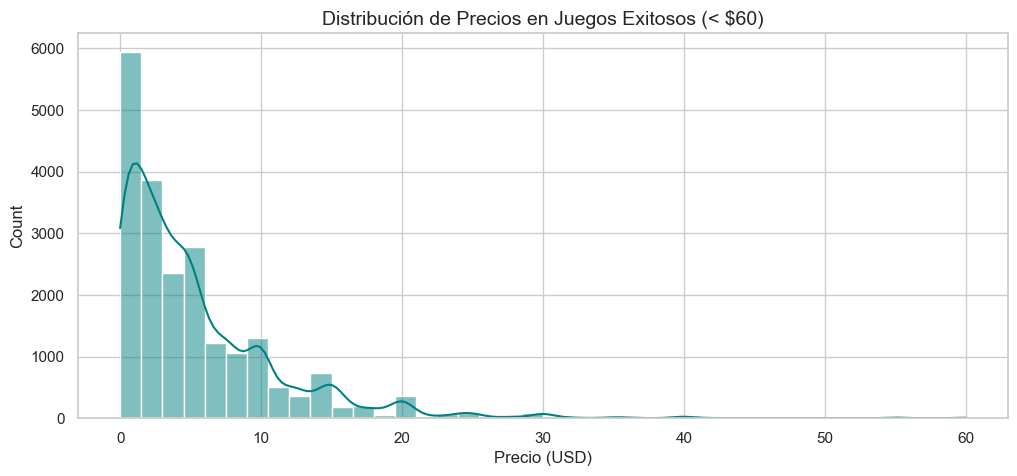

In [34]:
# A. Distribución de Precios
plt.figure(figsize=(12, 5))
sns.histplot(df[df['Price'] < 60]['Price'], bins=40, kde=True, color='teal')
plt.title('Distribución de Precios en Juegos Exitosos (< $60)', fontsize=14)
plt.xlabel('Precio (USD)')
plt.show()

C:\Users\dafem\AppData\Local\Temp\ipykernel_11512\3632077469.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='magma')


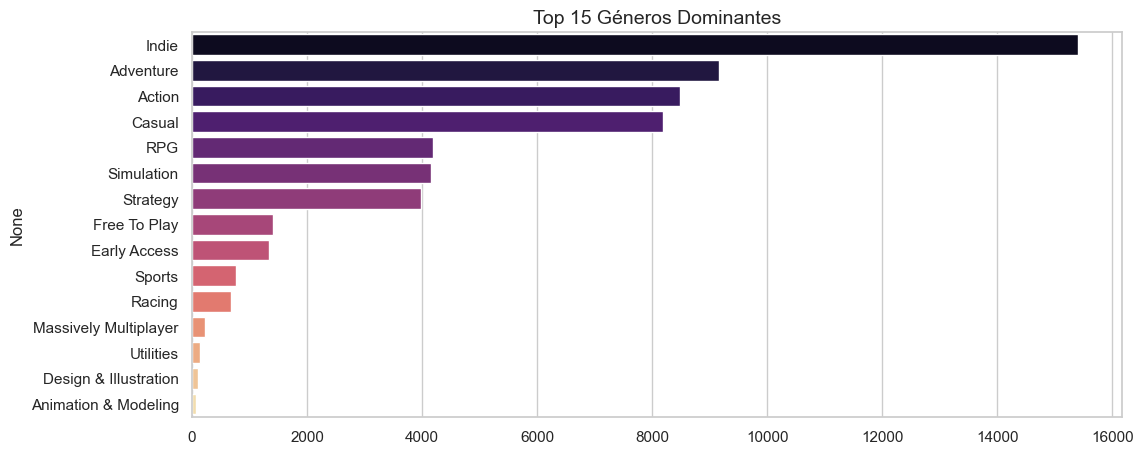

In [35]:
# B. Top 15 Géneros más comunes
genre_cols = [col for col in df.columns if col.startswith('genre_')]
genre_counts = df[genre_cols].sum().sort_values(ascending=False).head(15)
genre_counts.index = [name.replace('genre_', '') for name in genre_counts.index]

plt.figure(figsize=(12, 5))
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='magma')
plt.title('Top 15 Géneros Dominantes', fontsize=14)
plt.show()

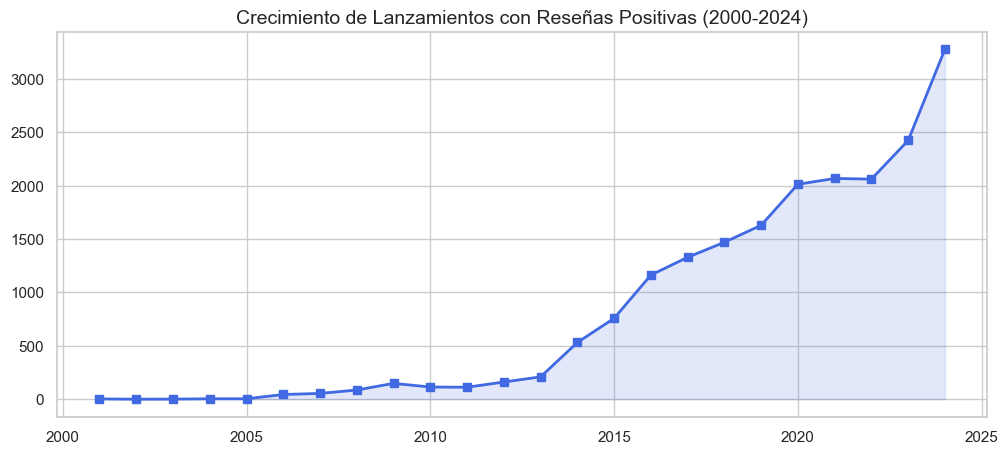

In [36]:
# C. Evolución Temporal de Lanzamientos Exitosos
yearly_counts = df[(df['Release_year'] > 2000) & (df['Release_year'] <= 2024)]['Release_year'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.plot(yearly_counts.index, yearly_counts.values, marker='s', color='royalblue', linewidth=2)
plt.fill_between(yearly_counts.index, yearly_counts.values, alpha=0.15, color='royalblue')
plt.title('Crecimiento de Lanzamientos con Reseñas Positivas (2000-2024)', fontsize=14)
plt.show()

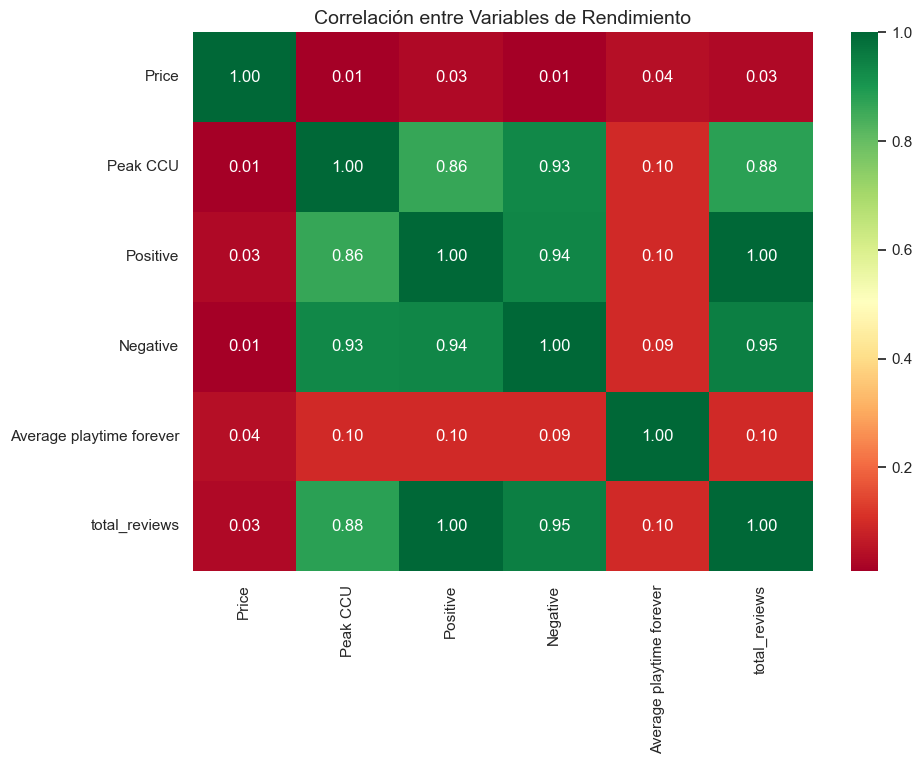

In [37]:
# D. Mapa de Correlación entre Métricas Numéricas
num_cols = ['Price', 'Peak CCU', 'Positive', 'Negative', 'Average playtime forever', 'total_reviews']
plt.figure(figsize=(10, 7))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='RdYlGn', fmt=".2f")
plt.title('Correlación entre Variables de Rendimiento', fontsize=14)
plt.show()

### 2.2 Visualizaciones Avanzadas

C:\Users\dafem\AppData\Local\Temp\ipykernel_11512\815856711.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tag_counts.values, y=tag_counts.index, palette='viridis')


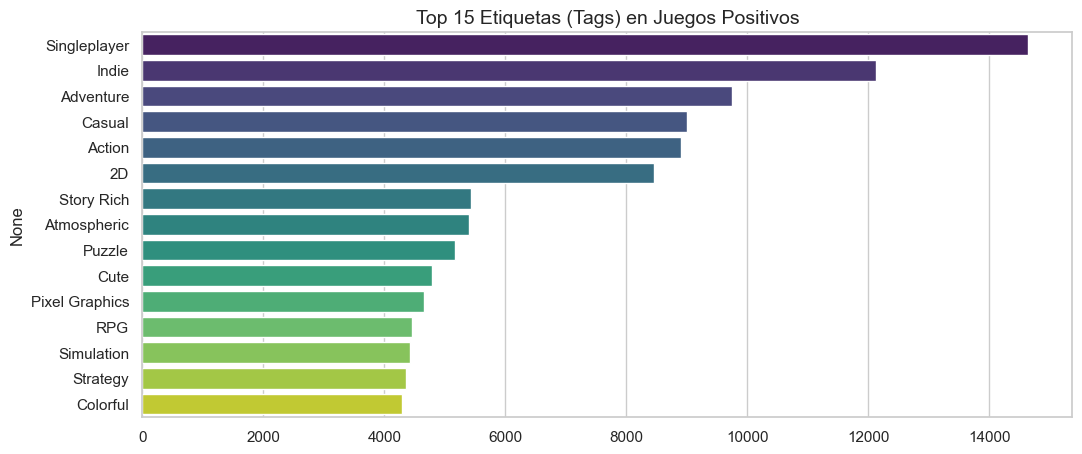

In [38]:
# E. Top 15 Etiquetas (Tags) más comunes
tag_cols = [col for col in df.columns if col.startswith('tag_')]
tag_counts = df[tag_cols].sum().sort_values(ascending=False).head(15)
tag_counts.index = [name.replace('tag_', '') for name in tag_counts.index]

plt.figure(figsize=(12, 5))
sns.barplot(x=tag_counts.values, y=tag_counts.index, palette='viridis')
plt.title('Top 15 Etiquetas (Tags) en Juegos Positivos', fontsize=14)
plt.show()

C:\Users\dafem\AppData\Local\Temp\ipykernel_11512\1862016123.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sales_cat', palette='Set2', order=df['sales_cat'].value_counts().index)


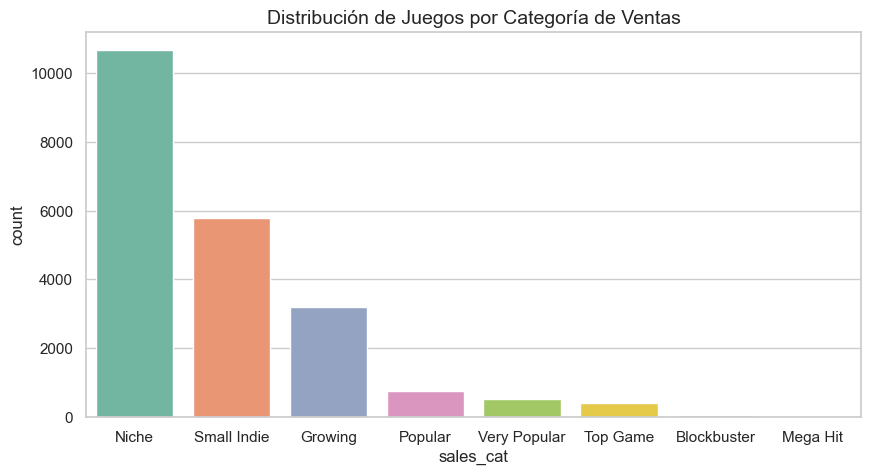

In [39]:
# F. Distribución por Categoría de Ventas (sales_cat)
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='sales_cat', palette='Set2', order=df['sales_cat'].value_counts().index)
plt.title('Distribución de Juegos por Categoría de Ventas', fontsize=14)
plt.show()

C:\Users\dafem\AppData\Local\Temp\ipykernel_11512\3233835131.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Release_season', palette='coolwarm', order=season_order)


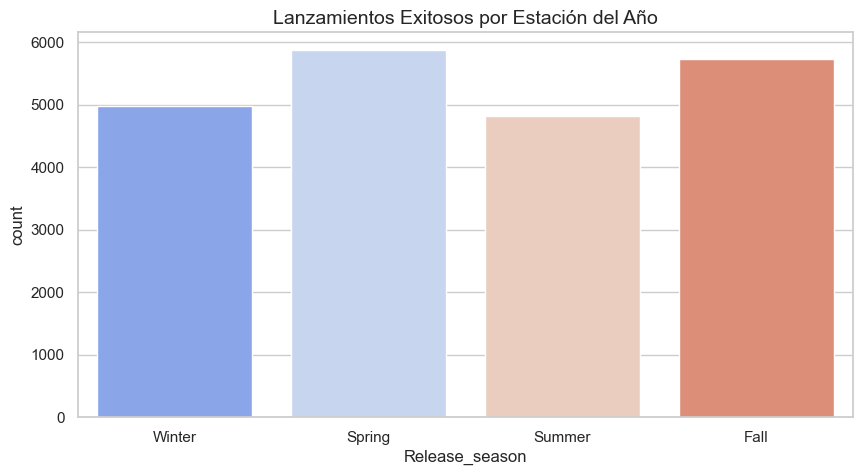

In [40]:
# G. Análisis de Estacionalidad de Lanzamientos
season_order = ['Winter', 'Spring', 'Summer', 'Fall']
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Release_season', palette='coolwarm', order=season_order)
plt.title('Lanzamientos Exitosos por Estación del Año', fontsize=14)
plt.show()

C:\Users\dafem\AppData\Local\Temp\ipykernel_11512\3518217859.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sales_cat', y='Average playtime forever', palette='Set3')


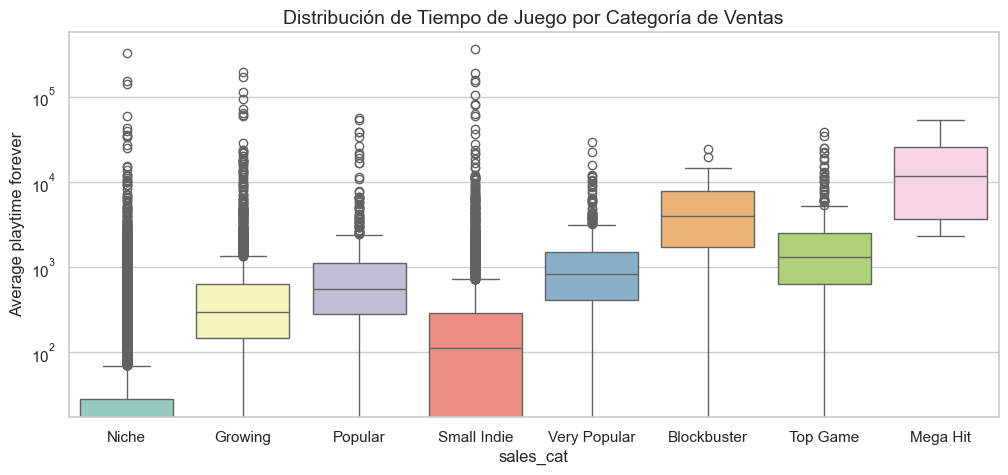

In [41]:
# H. Tiempo de Juego vs Categoría de Ventas
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='sales_cat', y='Average playtime forever', palette='Set3')
plt.yscale('log')
plt.title('Distribución de Tiempo de Juego por Categoría de Ventas', fontsize=14)
plt.show()

--- 

## 3. Análisis de Reglas de Asociación (Apriori)

Buscamos relaciones entre géneros y etiquetas que definen a los juegos exitosos.

In [42]:
# 1. Preparación: Seleccionamos los 50 elementos más frecuentes para eficiencia
binary_cols = [col for col in df.columns if col.startswith('genre_') or col.startswith('tag_')]
top_elements = df[binary_cols].sum().sort_values(ascending=False).head(50).index
df_filtered_binary = df[top_elements]

# 2. Ejecución de Apriori
print("⌛ Calculando combinaciones frecuentes... ")
frequent_itemsets = apriori(df_filtered_binary, min_support=0.05, use_colnames=True)

# 3. Generación de Reglas
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.2)
rules = rules.sort_values(by='lift', ascending=False)

print(f"✅ Se han generado {len(rules)} reglas de asociación.")
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)

⌛ Calculando combinaciones frecuentes... 


c:\Users\dafem\.pyenv\pyenv-win\versions\3.14.2\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


✅ Se han generado 12926 reglas de asociación.


,antecedents,consequents,support,confidence,lift
7296,"frozenset({genre_Action, tag_RPG})","frozenset({genre_RPG, tag_Action})",0.055493,0.767292,11.157285
7299,"frozenset({genre_RPG, tag_Action})","frozenset({genre_Action, tag_RPG})",0.055493,0.806934,11.157285
7298,"frozenset({tag_RPG, tag_Action})","frozenset({genre_Action, genre_RPG})",0.055493,0.722459,10.620891
7297,"frozenset({genre_Action, genre_RPG})","frozenset({tag_RPG, tag_Action})",0.055493,0.815808,10.620891
7243,"frozenset({tag_Casual, genre_Strategy})","frozenset({tag_Strategy, genre_Casual})",0.060262,0.786455,10.146125
7244,"frozenset({tag_Strategy, genre_Casual})","frozenset({tag_Casual, genre_Strategy})",0.060262,0.777443,10.146125
12526,"frozenset({tag_Indie, genre_Adventure, genre_R...","frozenset({genre_Indie, tag_RPG, tag_Adventure})",0.050958,0.864393,9.892656
12529,"frozenset({genre_Indie, tag_RPG, tag_Adventure})","frozenset({tag_Indie, genre_Adventure, genre_R...",0.050958,0.583200,9.892656
12519,"frozenset({tag_Indie, genre_Adventure, tag_RPG})","frozenset({genre_RPG, genre_Indie, tag_Adventu...",0.050958,0.823885,9.823246
12536,"frozenset({genre_RPG, genre_Indie, tag_Adventu...","frozenset({tag_Indie, genre_Adventure, tag_RPG})",0.050958,0.607581,9.823246


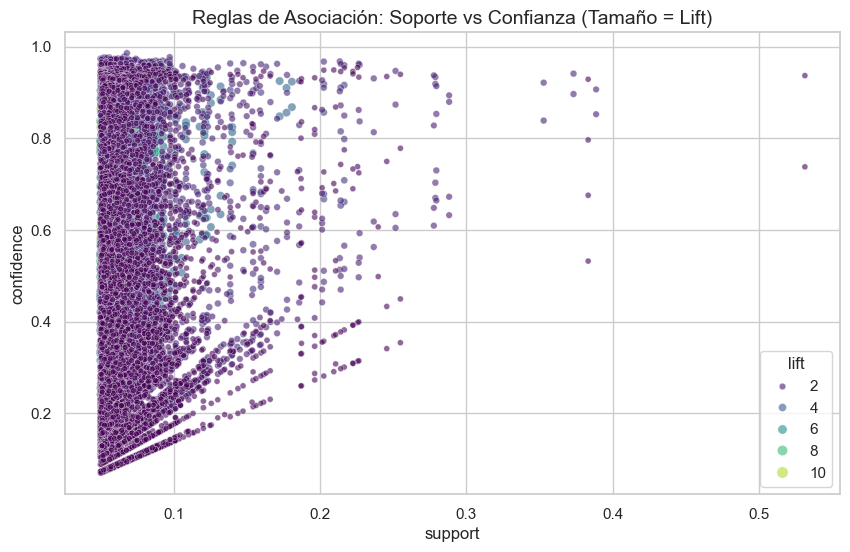

In [43]:
# Visualización: Soporte vs Confianza
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rules, x="support", y="confidence", size="lift", hue="lift", palette="viridis", alpha=0.6)
plt.title('Reglas de Asociación: Soporte vs Confianza (Tamaño = Lift)', fontsize=14)
plt.show()

C:\Users\dafem\AppData\Local\Temp\ipykernel_11512\3133016727.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_rules, x='lift', y='rule', palette='flare')


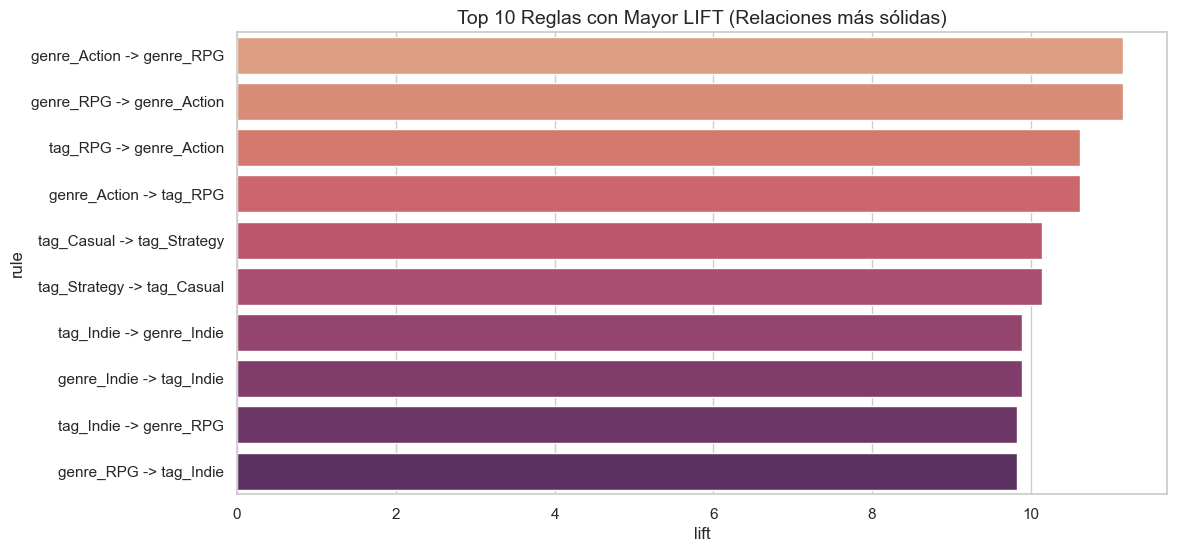

In [44]:
# Top 10 Reglas por Lift
top_rules = rules.head(10).copy()
top_rules['rule'] = top_rules['antecedents'].apply(lambda x: list(x)[0]) + " -> " + top_rules['consequents'].apply(lambda x: list(x)[0])

plt.figure(figsize=(12, 6))
sns.barplot(data=top_rules, x='lift', y='rule', palette='flare')
plt.title('Top 10 Reglas con Mayor LIFT (Relaciones más sólidas)', fontsize=14)
plt.show()

--- 

## 4. Próximos Pasos

1.  **Clasificación:** Predecir el éxito de ventas basándonos en estas asociaciones.
2.  **Agrupación (Clustering):** Segmentar los juegos en perfiles de éxito.